In [61]:
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import random
import matplotlib.pyplot as plt


data_folder = Path("Battery_life_Dataset/Tongji")

pkl_files = list(data_folder.glob("*.pkl"))
selected_files = random.sample(pkl_files, 3)

datasets = []

for pkl_file in selected_files:
    with open(pkl_file, "rb") as f:
        datasets.append(pickle.load(f))

print([d["cell_id"] for d in datasets])

['Tongji1_CY25-1_1--5', 'Tongji1_CY45-05_1--15', 'Tongji1_CY25-1_1--3']


In [ ]:
# Variablen definieren

# Cyclenschritt

step = 5

In [62]:
# Data compression function (not used in final code, but could be useful for future work)

# def compress_curve(time, current, threshold=0.5):

#     time = np.asarray(time)
#     current = np.asarray(current)

#     compressed_t = []
#     compressed_I = []

#     start = 0

#     for i in range(1, len(current)):

#         if abs(current[i] - current[i-1]) > threshold:

#             compressed_t.append(np.mean(time[start:i]))
#             compressed_I.append(np.mean(current[start:i]))

#             start = i

#     # letztes Segment
#     compressed_t.append(np.mean(time[start:]))
#     compressed_I.append(np.mean(current[start:]))

#     return np.array(compressed_t), np.array(compressed_I)

In [63]:
# Beispiel für die Verwendung der Kompressionsfunktion

# cycle = datasets[0]["cycle_data"][1]

# t = cycle["time_in_s"]
# I = cycle["current_in_A"]

# t_red, I_red = compress_curve(
#     t,
#     I,
#     threshold=0.5
# )

# print(len(I))
# print(len(I_red))

In [64]:
# Visualisierung der Original- und komprimierten Kurven

# plt.figure(figsize=(10,4))

# plt.plot(t, I, alpha=0.4, label="original")

# plt.plot(
#     t_red,
#     I_red,
#     "o-",
#     label="compressed"
# )

# plt.legend()
# plt.show()

In [ ]:
# # Feature-Engineering: Berechnung von SOH und Stromstatistiken

# features = []

# for data in datasets:

#     cycles = data["cycle_data"]

#     # Referenzkapazität aus Zyklus 2
#     Q0 = np.max(cycles[1]["discharge_capacity_in_Ah"])

#     for cycle in cycles:

#         I_var = np.array(cycle["current_in_A"], dtype=np.float32)

#         Q_discharge = np.max(cycle["discharge_capacity_in_Ah"])

#         soh = Q_discharge / Q0

#         features.append({
#             "cell_id": data["cell_id"],
#             "cycle_number": cycle["cycle_number"],
#             "SOH": soh,
#             "I_mean": np.mean(I_var),
#             "I_std": np.std(I_var)
#         })

# feature_df = pd.DataFrame(features)

# print(feature_df.head(20))

                cell_id  cycle_number       SOH    I_mean     I_std
0   Tongji1_CY25-1_1--5             2  0.998717  0.006703  2.712845
1   Tongji1_CY25-1_1--5             3  1.000000  0.014126  2.682710
2   Tongji1_CY25-1_1--5             4  0.998923  0.015656  2.669867
3   Tongji1_CY25-1_1--5             5  0.998556  0.017670  2.652017
4   Tongji1_CY25-1_1--5             6  0.995027  0.014165  2.646689
5   Tongji1_CY25-1_1--5             7  0.991483  0.008386  2.631645
6   Tongji1_CY25-1_1--5             8  0.987277  0.001224  2.620487
7   Tongji1_CY25-1_1--5             9  0.982910 -0.011479  2.613210
8   Tongji1_CY25-1_1--5            10  0.976742 -0.017748  2.602432
9   Tongji1_CY25-1_1--5            11  0.970124 -0.023386  2.585094
10  Tongji1_CY25-1_1--5            12  0.964142 -0.036539  2.575062
11  Tongji1_CY25-1_1--5            13  0.957051 -0.039446  2.566766
12  Tongji1_CY25-1_1--5            14  0.949584 -0.045110  2.548665
13  Tongji1_CY25-1_1--5            15  0.942148 

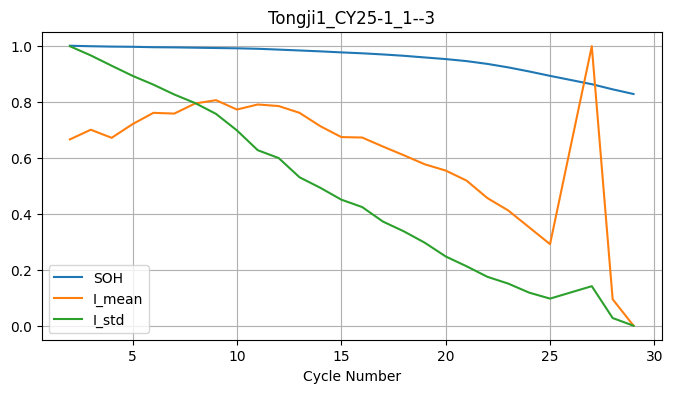

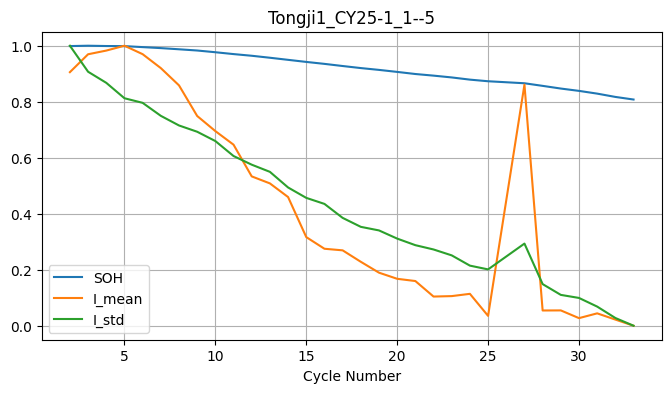

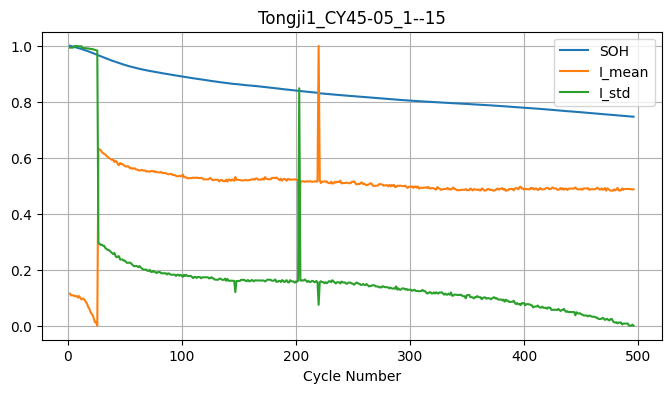

In [ ]:
# Visualisierung der SOH- und Stromstatistiken für die ausgewählten Zellen

# for cell_id, group in feature_df.groupby("cell_id"):

#     plt.figure(figsize=(8,4))

#     soh = group["SOH"]

#     I_mean = (
#         group["I_mean"] - group["I_mean"].min()
#     ) / (
#         group["I_mean"].max() - group["I_mean"].min()
#     )

#     I_std = (
#         group["I_std"] - group["I_std"].min()
#     ) / (
#         group["I_std"].max() - group["I_std"].min()
#     )

#     plt.plot(group["cycle_number"], soh, label="SOH")
#     plt.plot(group["cycle_number"], I_mean, label="I_mean")
#     plt.plot(group["cycle_number"], I_std, label="I_std")

#     plt.title(cell_id)
#     plt.xlabel("Cycle Number")

#     plt.legend()
#     plt.grid(True)

#     plt.show()

In [67]:
features = []

for data in datasets:

    cycles = data["cycle_data"]

    Q0 = np.max(cycles[1]["discharge_capacity_in_Ah"])

    for cycle in cycles:

        I = np.array(cycle["current_in_A"], dtype=np.float32)
        V = np.array(cycle["voltage_in_V"], dtype=np.float32)
        t = np.array(cycle["time_in_s"], dtype=np.float32)

        # SOH
        Q_discharge = np.max(cycle["discharge_capacity_in_Ah"])
        soh = Q_discharge / Q0

        # Zeitdifferenzen
        dt = np.diff(t, prepend=t[0])

        charge_duration = np.sum(dt[I > 0])
        discharge_duration = np.sum(dt[I < 0])

        features.append({
            "cell_id": data["cell_id"],
            "cycle_number": cycle["cycle_number"],

            "SOH": soh,

            "I_mean": np.mean(I),
            "I_std": np.std(I),

            "charge_duration": charge_duration,
            "discharge_duration": discharge_duration,

            "V_mean": np.mean(V),
            "V_std": np.std(V)
        })

feature_df = pd.DataFrame(features)

print(feature_df.head())

               cell_id  cycle_number       SOH    I_mean     I_std  \
0  Tongji1_CY25-1_1--5             2  0.998717  0.006703  2.712845   
1  Tongji1_CY25-1_1--5             3  1.000000  0.014126  2.682710   
2  Tongji1_CY25-1_1--5             4  0.998923  0.015656  2.669867   
3  Tongji1_CY25-1_1--5             5  0.998556  0.017670  2.652017   
4  Tongji1_CY25-1_1--5             6  0.995027  0.014165  2.646689   

   charge_duration  discharge_duration    V_mean     V_std  
0      5794.882324         3314.273926  3.779736  0.468391  
1      5968.900391         3318.486328  3.790289  0.466329  
2      6060.066406         3314.976562  3.794991  0.466191  
3      6160.738281         3313.765625  3.802270  0.464157  
4      6174.496094         3302.484375  3.805017  0.463322  


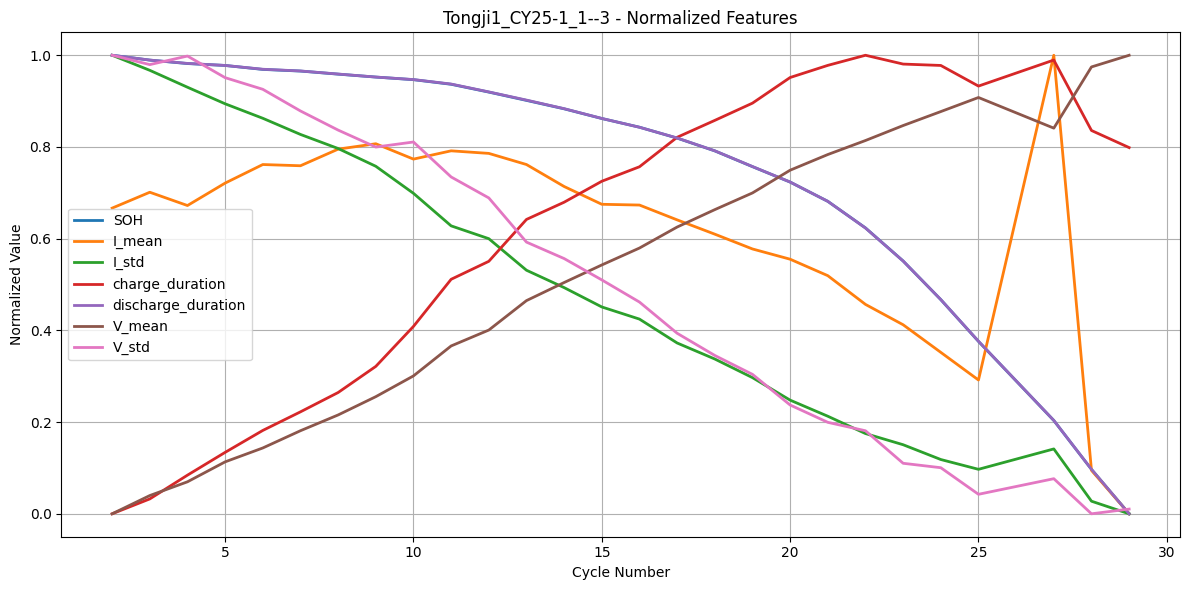

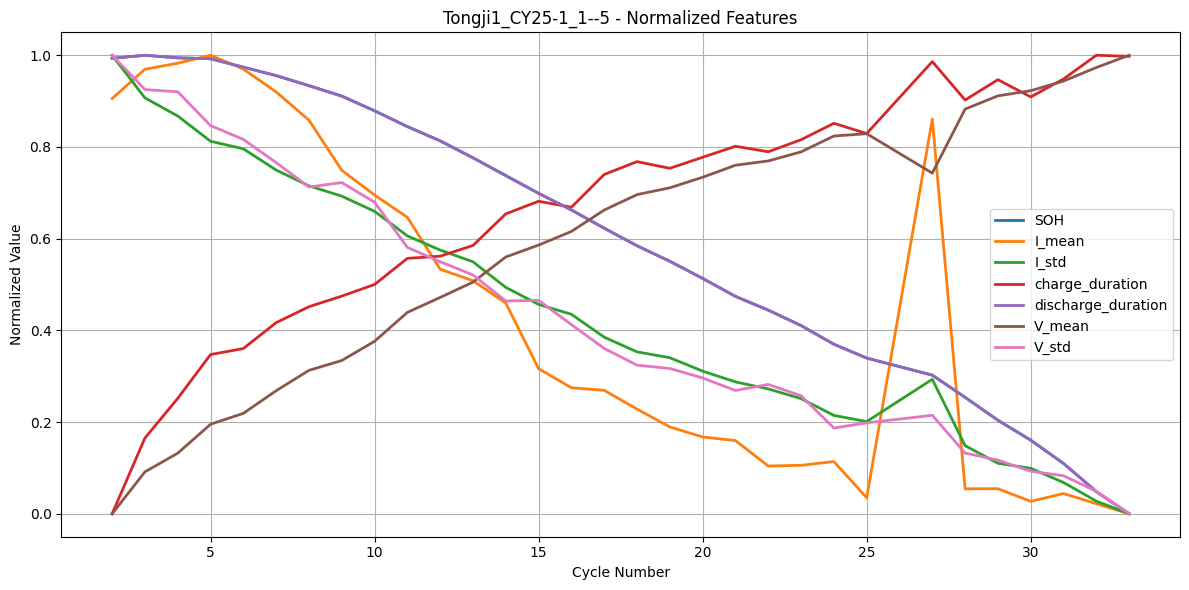

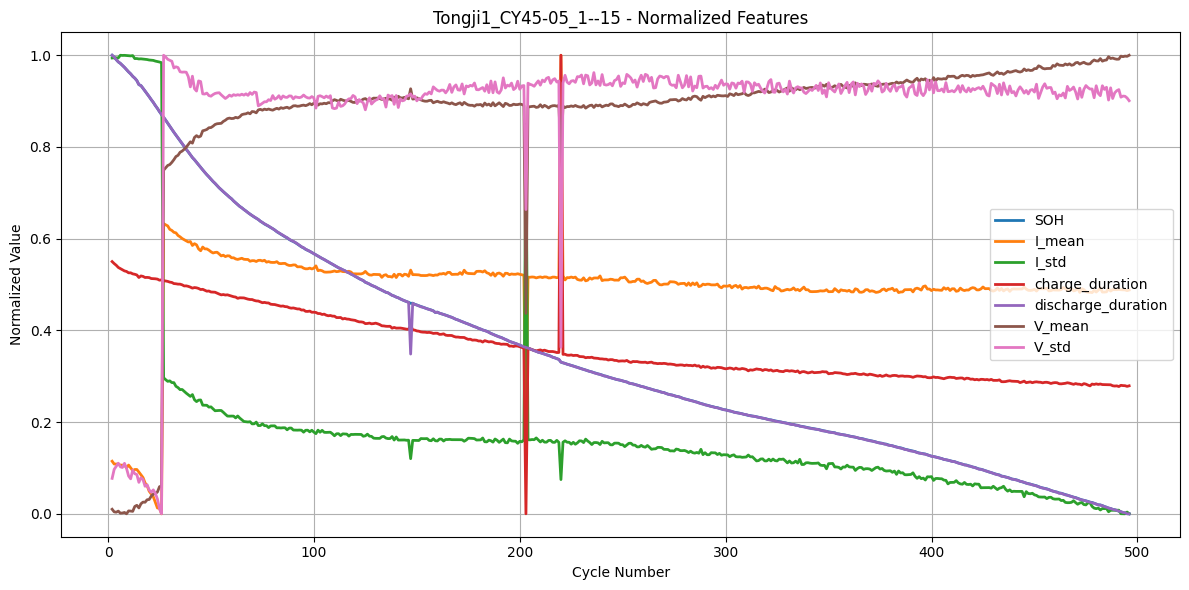

In [68]:
feature_cols = [
    "SOH",
    "I_mean",
    "I_std",
    "charge_duration",
    "discharge_duration",
    "V_mean",
    "V_std"
]

for cell_id, group in feature_df.groupby("cell_id"):

    plt.figure(figsize=(12, 6))

    for feature in feature_cols:

        values = group[feature].values

        # Min-Max-Normierung
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        if vmax > vmin:
            values_norm = (values - vmin) / (vmax - vmin)
        else:
            values_norm = np.zeros_like(values)

        plt.plot(
            group["cycle_number"],
            values_norm,
            label=feature,
            linewidth=2
        )

    plt.title(f"{cell_id} - Normalized Features")
    plt.xlabel("Cycle Number")
    plt.ylabel("Normalized Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [77]:
# DTW-Feature: Dynamische Zeitverschiebung der Stromkurven
from dtaidistance import dtw

dtw_features = []

for data in datasets:

    cycles = data["cycle_data"]

    # reduzierte Zyklusliste
    cycles_red = cycles[::step]

    ref = np.array(cycles_red[1]["current_in_A"], dtype=np.float32)
    ref = (ref - np.mean(ref)) / (np.std(ref) + 1e-8)

    for cycle in cycles_red:

        x = np.array(cycle["current_in_A"], dtype=np.float32)
        x = (x - np.mean(x)) / (np.std(x) + 1e-8)

        dist = dtw.distance(ref, x)

        dtw_features.append({
            "cell_id": data["cell_id"],
            "cycle_number": cycle["cycle_number"],
            "DTW_I": dist
        })

dtw_df = pd.DataFrame(dtw_features)

In [78]:
feature_df = feature_df.merge(
    dtw_df,
    on=["cell_id", "cycle_number"],
    how="left"
)

In [79]:
import matplotlib.pyplot as plt

for cell_id, group in feature_df.groupby("cell_id"):

    plt.figure(figsize=(6,4))

    plt.scatter(group["DTW_I"], group["SOH"])

    plt.xlabel("DTW (current)")
    plt.ylabel("SOH")
    plt.title(cell_id)
    plt.grid(True)

    plt.show()

KeyError: 'DTW_I'

<Figure size 600x400 with 0 Axes>

In [ ]:
from dtaidistance import dtw
import numpy as np
import pandas as pd

dtw_v_features = []

for data in datasets:

    cycles = data["cycle_data"]

    # reduzierte Zyklusliste
    cycles_red = cycles[::step]

    ref_v = np.array(cycles_red[1]["voltage_in_V"], dtype=np.float32)
    ref_v = (ref_v - np.mean(ref_v)) / (np.std(ref_v) + 1e-8)

    for cycle in cycles_red:

        v = np.array(cycle["voltage_in_V"], dtype=np.float32)
        v = (v - np.mean(v)) / (np.std(v) + 1e-8)

        dist_v = dtw.distance(ref_v, v)

        dtw_v_features.append({
            "cell_id": data["cell_id"],
            "cycle_number": cycle["cycle_number"],
            "DTW_V": dist_v
        })

dtw_v_df = pd.DataFrame(dtw_v_features)

In [73]:
feature_df = feature_df.merge(
    dtw_v_df,
    on=["cell_id", "cycle_number"],
    how="left"
)

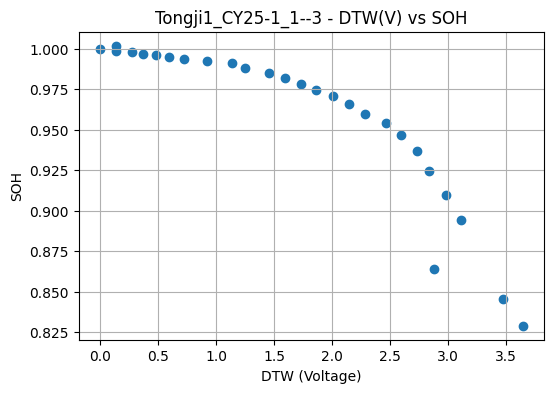

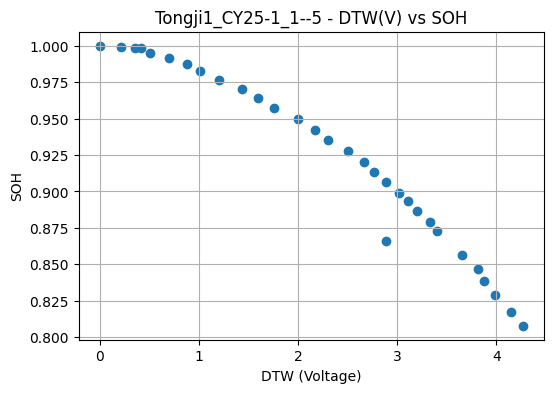

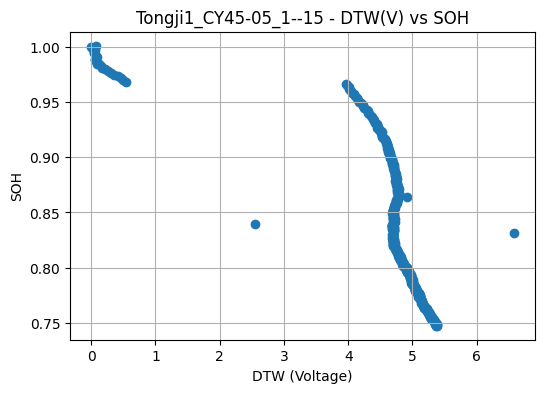

In [74]:
import matplotlib.pyplot as plt

for cell_id, group in feature_df.groupby("cell_id"):

    plt.figure(figsize=(6,4))

    plt.scatter(
        group["DTW_V"],
        group["SOH"]
    )

    plt.xlabel("DTW (Voltage)")
    plt.ylabel("SOH")
    plt.title(f"{cell_id} - DTW(V) vs SOH")
    plt.grid(True)

    plt.show()

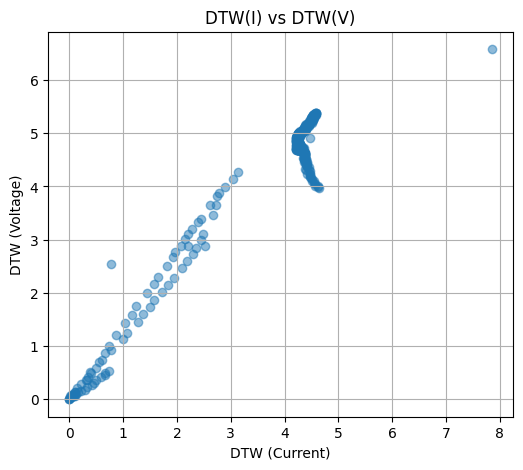

In [75]:
plt.figure(figsize=(6,5))

plt.scatter(
    feature_df["DTW_I"],
    feature_df["DTW_V"],
    alpha=0.5
)

plt.xlabel("DTW (Current)")
plt.ylabel("DTW (Voltage)")
plt.title("DTW(I) vs DTW(V)")
plt.grid(True)

plt.show()